Intelligent Book Recommendation System using Text Mining and Machine Learning

**Problem Statement:**

Online bookstores and digital libraries contain thousands of books spanning multiple genres and topics. Users often struggle to discover books that match their interests because of the vast amount of available content. Traditional search systems rely mainly on keywords and may fail to identify books that are semantically similar or relevant to a user’s preferences.
The objective of this project is to design and develop an Intelligent Book Recommendation System that uses Text Mining and Machine Learning techniques to recommend books based on the textual content of book descriptions, summaries, genres, and user-selected books.
Students are required to build a complete end-to-end system that can analyze textual information, extract meaningful features, compute similarities among books, and generate personalized recommendations. The system should provide an interactive interface through which users can search for a book and receive a list of similar books along with relevant information.
The project must demonstrate the complete machine learning pipeline including data collection, exploratory data analysis, text preprocessing, feature extraction, recommendation generation, evaluation, and deployment.

# Intelligent Book Recommendation System using Text Mining and Machine Learning

## Step 1: Import Required Libraries

This section imports all the Python libraries required for data analysis, text preprocessing, visualization, machine learning, and recommendation generation.

In [ ]:
# ================================
# Import Required Libraries
# ================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Machine Learning
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Word Cloud
from wordcloud import WordCloud

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("All libraries imported successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


All libraries imported successfully!


## Step 2: Load the Dataset

The dataset is loaded into a Pandas DataFrame. Initial inspection is performed to understand its structure, dimensions, and available features before preprocessing.

In [ ]:
# ================================
# Load Dataset
# ================================

from google.colab import files

uploaded = files.upload()

# Replace with your uploaded filename if different
df = pd.read_csv("Book_Details.csv")

print("Dataset loaded successfully!\n")

# Display dataset shape
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Saving Book_Details.csv to Book_Details (1).csv
Dataset loaded successfully!

Number of Rows    : 16225
Number of Columns : 15


In [ ]:
df = pd.read_csv("Book_Details.csv")

In [ ]:
# Display first five records
df.head()

,Unnamed: 0,book_id,cover_image_uri,book_title,book_details,format,publication_info,authorlink,author,num_pages,genres,num_ratings,num_reviews,average_rating,rating_distribution
0,0,1,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Half-Blood Prince,"It is the middle of the summer, but there is a...","['652 pages, Paperback']","['First published July 16, 2005']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,['652'],"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...",3292516,58398,4.58,"{'5': '2,244,154', '4': '775,028', '3': '219,8..."
1,1,2,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Order of the Phoenix,Harry Potter is about to start his fifth year ...,"['912 pages, Paperback']","['First published June 21, 2003']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,['912'],"['Young Adult', 'Fiction', 'Magic', 'Childrens...",3401709,64300,4.50,"{'5': '2,178,760', '4': '856,178', '3': '293,2..."
2,2,3,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Sorcerer's Stone,Harry Potter has no idea how famous he is. Tha...,"['309 pages, Hardcover']","['First published June 26, 1997']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,['309'],"['Fantasy', 'Fiction', 'Young Adult', 'Magic',...",10116247,163493,4.47,"{'5': '6,544,542', '4': '2,348,390', '3': '856..."
3,3,5,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Prisoner of Azkaban,"Harry Potter, along with his best friends, Ron...","['435 pages, Mass Market Paperback']","['First published July 8, 1999']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,['435'],"['Fantasy', 'Fiction', 'Young Adult', 'Magic',...",4215031,84959,4.58,"{'5': '2,892,322', '4': '970,190', '3': '287,7..."
4,4,6,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Goblet of Fire,It is the summer holidays and soon Harry Potte...,"['734 pages, Paperback']","['First published July 8, 2000']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,['734'],"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...",3718209,69961,4.57,"{'5': '2,500,070', '4': '899,496', '3': '259,7..."


In [ ]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16225 entries, 0 to 16224
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           16225 non-null  int64  
 1   book_id              16225 non-null  int64  
 2   cover_image_uri      16225 non-null  object 
 3   book_title           16225 non-null  object 
 4   book_details         16177 non-null  object 
 5   format               16225 non-null  object 
 6   publication_info     16225 non-null  object 
 7   authorlink           16225 non-null  object 
 8   author               16225 non-null  object 
 9   num_pages            16225 non-null  object 
 10  genres               16225 non-null  object 
 11  num_ratings          16225 non-null  int64  
 12  num_reviews          16225 non-null  int64  
 13  average_rating       16225 non-null  float64
 14  rating_distribution  16225 non-null  object 
dtypes: float64(1), int64(4), object(10)


In [ ]:
# Display column names
print(df.columns.tolist())

['Unnamed: 0', 'book_id', 'cover_image_uri', 'book_title', 'book_details', 'format', 'publication_info', 'authorlink', 'author', 'num_pages', 'genres', 'num_ratings', 'num_reviews', 'average_rating', 'rating_distribution']


## Step 3: Data Cleaning

Data cleaning is an important step in the machine learning pipeline. It ensures that the dataset is free from missing values, duplicate records, and inconsistent data. A clean dataset improves the quality and reliability of the recommendation system.

In [ ]:
# ================================
# Dataset Shape
# ================================

print("Rows and Columns:", df.shape)

Rows and Columns: (16225, 15)


In [ ]:
# ================================
# Missing Values
# ================================

missing_values = df.isnull().sum()

print("Missing Values in Each Column:\n")
print(missing_values)

Missing Values in Each Column:

Unnamed: 0              0
book_id                 0
cover_image_uri         0
book_title              0
book_details           48
format                  0
publication_info        0
authorlink              0
author                  0
num_pages               0
genres                  0
num_ratings             0
num_reviews             0
average_rating          0
rating_distribution     0
dtype: int64


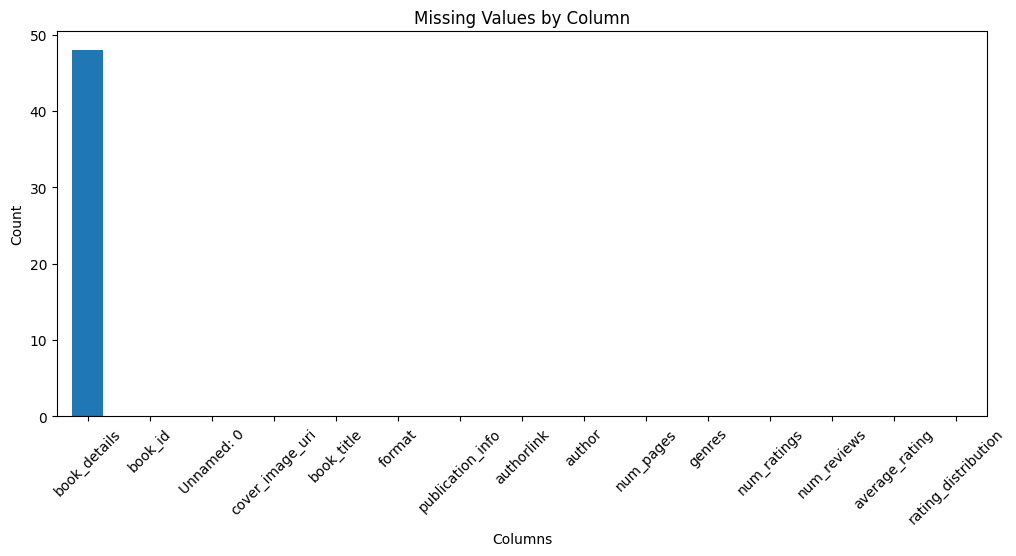

In [ ]:
plt.figure(figsize=(12,5))

missing_values.sort_values(ascending=False).plot(kind='bar')

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

In [ ]:
# ================================
# Remove Missing Values
# ================================

df = df.dropna(subset=[
    'book_title',
    'author',
    'genres',
    'book_details'
])

print("Dataset Shape After Removing Missing Values:")
print(df.shape)

Dataset Shape After Removing Missing Values:
(16177, 15)


In [ ]:
# ================================
# Duplicate Records
# ================================

duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [ ]:
# ================================
# Remove Duplicate Books
# ================================

df = df.drop_duplicates(subset='book_title')

print("Dataset Shape After Removing Duplicates:")
print(df.shape)

Dataset Shape After Removing Duplicates:
(15443, 15)


In [ ]:
# ================================
# Data Types
# ================================

print(df.dtypes)

Unnamed: 0               int64
book_id                  int64
cover_image_uri         object
book_title              object
book_details            object
format                  object
publication_info        object
authorlink              object
author                  object
num_pages               object
genres                  object
num_ratings              int64
num_reviews              int64
average_rating         float64
rating_distribution     object
dtype: object


In [ ]:
# ================================
# Clean Text Columns
# ================================

text_columns = [
    'book_title',
    'author',
    'genres',
    'book_details'
]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

print("Text columns cleaned successfully.")

Text columns cleaned successfully.


In [ ]:
# Drop unnecessary index column
df.drop(columns=['Unnamed: 0'], inplace=True)

print(df.shape)

(15443, 14)


In [ ]:
# ================================
# Final Dataset Information
# ================================

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 15443 entries, 0 to 16224
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   book_id              15443 non-null  int64  
 1   cover_image_uri      15443 non-null  object 
 2   book_title           15443 non-null  object 
 3   book_details         15443 non-null  object 
 4   format               15443 non-null  object 
 5   publication_info     15443 non-null  object 
 6   authorlink           15443 non-null  object 
 7   author               15443 non-null  object 
 8   num_pages            15443 non-null  object 
 9   genres               15443 non-null  object 
 10  num_ratings          15443 non-null  int64  
 11  num_reviews          15443 non-null  int64  
 12  average_rating       15443 non-null  float64
 13  rating_distribution  15443 non-null  object 
dtypes: float64(1), int64(3), object(10)
memory usage: 1.8+ MB
None


# Step 4: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps understand the characteristics of the dataset through statistical summaries and visualizations. This step identifies patterns, trends, and relationships among the features before building the recommendation system.

In [ ]:
# ================================
# Statistical Summary
# ================================
print("Numerical Summary")
display(df.describe())


Numerical Summary


,book_id,num_ratings,num_reviews,average_rating
count,1.544300e+04,1.544300e+04,15443.000000,15443.000000
mean,9.899876e+06,7.616866e+04,4506.512918,4.001013
std,2.110278e+07,2.838572e+05,12966.724154,0.330318
min,1.000000e+00,0.000000e+00,0.000000,0.000000
25%,8.989500e+04,2.834500e+03,197.000000,3.830000
50%,8.343780e+05,1.541800e+04,952.000000,4.030000
75%,9.973884e+06,5.360500e+04,3299.000000,4.210000
max,2.096076e+08,1.011625e+07,274695.000000,5.000000


In [ ]:
print("Categorical Summary")
display(df.describe(include=['object']))

Categorical Summary


,cover_image_uri,book_title,book_details,format,publication_info,authorlink,author,num_pages,genres,rating_distribution
count,15443,15443,15443,15443,15443,15443,15443,15443,15443,15443
unique,15420,15443,15415,3034,5266,7494,7494,1076,13509,15365
top,https://dryofg8nmyqjw.cloudfront.net/images/no...,Shadow's Siege,"Libro usado en buenas condiciones, por su anti...","['288 pages, Paperback']","['First published January 1, 2008']",https://www.goodreads.com/author/show/3389.Ste...,Stephen King,['320'],[],"{'5': '1', '4': '0', '3': '0', '2': '0', '1': ..."
freq,24,1,6,137,345,73,73,256,297,8


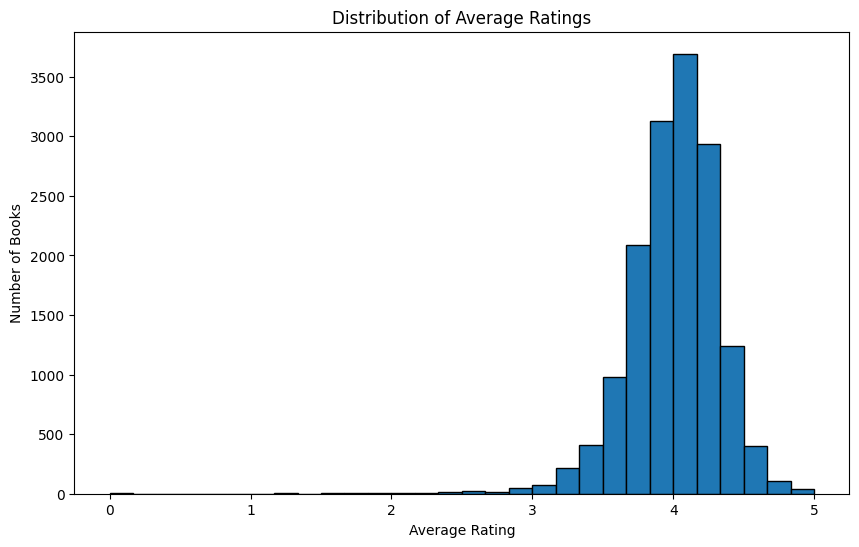

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(df['average_rating'], bins=30, edgecolor='black')

plt.title("Distribution of Average Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Number of Books")

plt.show()

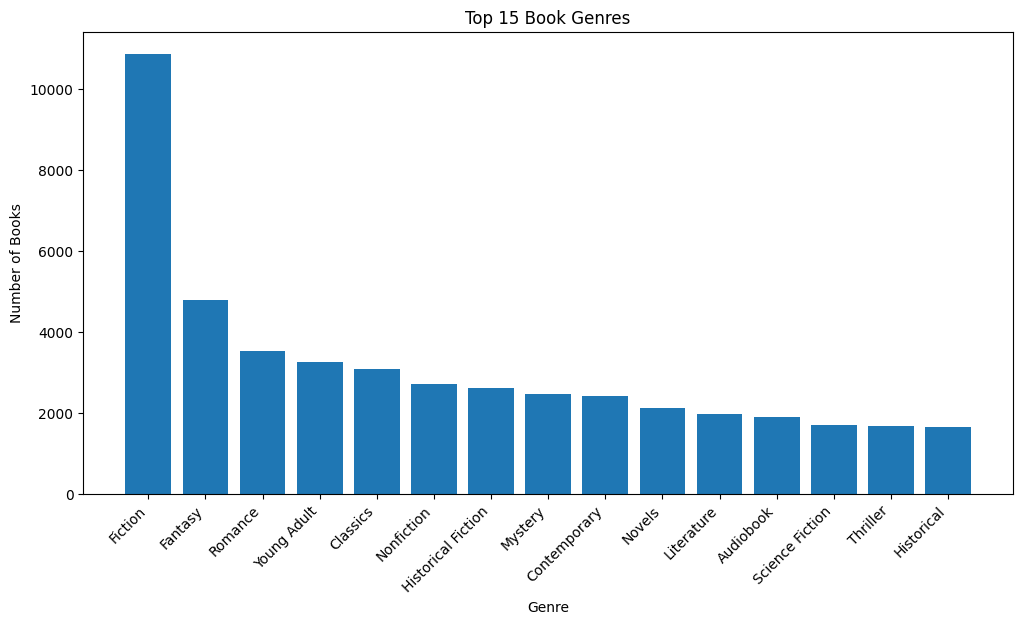

In [ ]:
import ast

genre_list = []

for genres in df['genres']:
    try:
        # Convert string representation of list to an actual Python list
        genre_values = ast.literal_eval(genres)

        # Remove extra spaces
        genre_values = [g.strip() for g in genre_values]

        genre_list.extend(genre_values)

    except:
        continue
from collections import Counter

genre_counts = Counter(genre_list)

top_genres = (
    pd.DataFrame(genre_counts.items(), columns=['Genre','Count'])
      .sort_values(by='Count', ascending=False)
      .head(15)
)

plt.figure(figsize=(12,6))

plt.bar(top_genres['Genre'], top_genres['Count'])

plt.xticks(rotation=45, ha='right')

plt.title("Top 15 Book Genres")

plt.xlabel("Genre")

plt.ylabel("Number of Books")

plt.show()

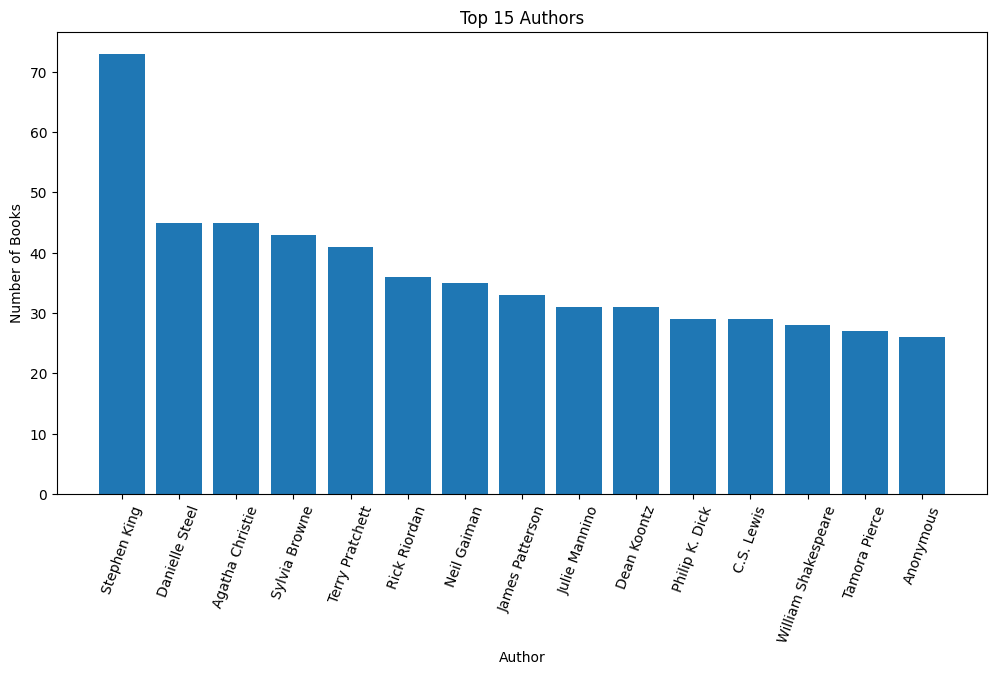

In [ ]:
top_authors = df['author'].value_counts().head(15)

plt.figure(figsize=(12,6))

plt.bar(top_authors.index, top_authors.values)

plt.xticks(rotation=70)

plt.title("Top 15 Authors")

plt.xlabel("Author")

plt.ylabel("Number of Books")

plt.show()

In [ ]:
# ================================
# Clean num_pages Column
# ================================

import ast
import numpy as np

def extract_pages(page):
    try:
        # Convert string representation of list to Python list
        page = ast.literal_eval(page)

        if len(page) > 0:
            return int(page[0])

    except:
        return np.nan

df['num_pages'] = df['num_pages'].apply(extract_pages)

print(df['num_pages'].head())

0    652.0
1    912.0
2    309.0
3    435.0
4    734.0
Name: num_pages, dtype: float64


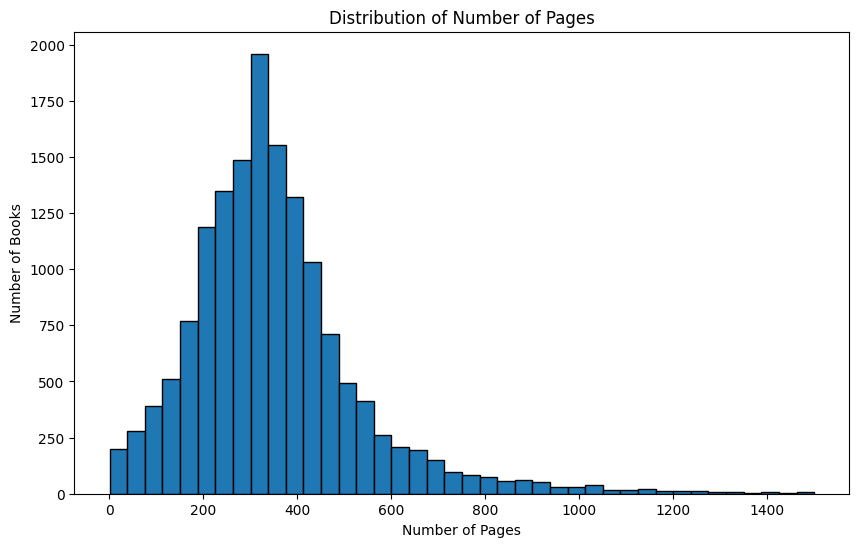

In [ ]:
pages = df[df['num_pages'] <= 1500]

plt.figure(figsize=(10,6))

plt.hist(
    pages['num_pages'],
    bins=40,
    edgecolor='black'
)

plt.title("Distribution of Number of Pages")
plt.xlabel("Number of Pages")
plt.ylabel("Number of Books")

plt.show()

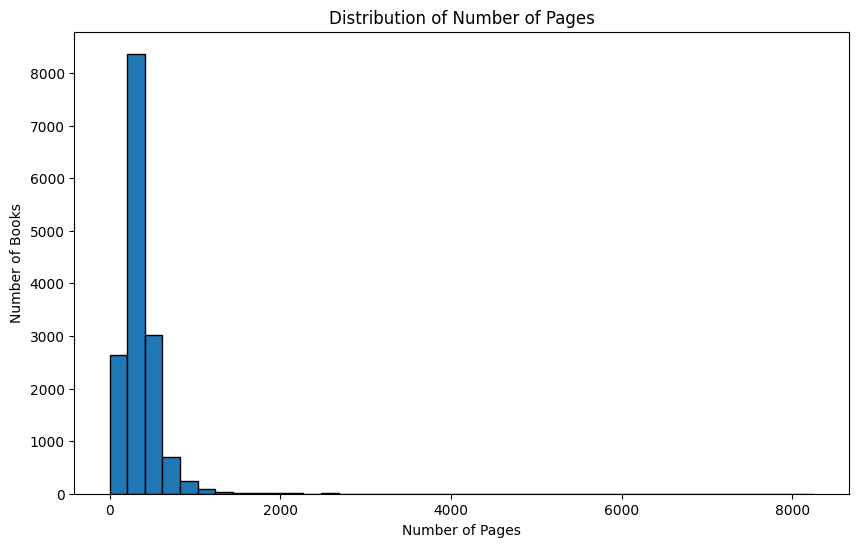

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    df['num_pages'].dropna(),
    bins=40,
    edgecolor='black'
)

plt.title("Distribution of Number of Pages")

plt.xlabel("Number of Pages")

plt.ylabel("Number of Books")

plt.show()

In [ ]:
top_books = (
    df[df['num_ratings'] >= 1000]
    .sort_values(by='average_rating', ascending=False)
    [['book_title', 'author', 'average_rating', 'num_ratings']]
    .head(10)
)

top_books

,book_title,author,average_rating,num_ratings
15834,Heaven Official's Blessing: Tian Guan Ci Fu (N...,Mò Xiāng Tóng Xiù,4.82,9453
15736,The Addiction Manifesto,Jerry Weaver,4.82,1160
12975,Сад Гетсиманський,Ivan Bahrianyi,4.82,1579
1867,The Complete Calvin and Hobbes,Bill Watterson,4.81,40335
7763,Nutuk,Mustafa Kemal Atatürk,4.81,5009
15630,All the Young Dudes - Volume Two: Years 5 - 7,MsKingBean89,4.81,17979
4083,Mark of the Lion Trilogy,Francine Rivers,4.78,13338
14798,All the Young Dudes,MsKingBean89,4.78,30436
15813,Heaven Official's Blessing: Tian Guan Ci Fu (N...,Mò Xiāng Tóng Xiù,4.78,13407
15835,Heaven Official's Blessing: Tian Guan Ci Fu (N...,Mò Xiāng Tóng Xiù,4.76,7814


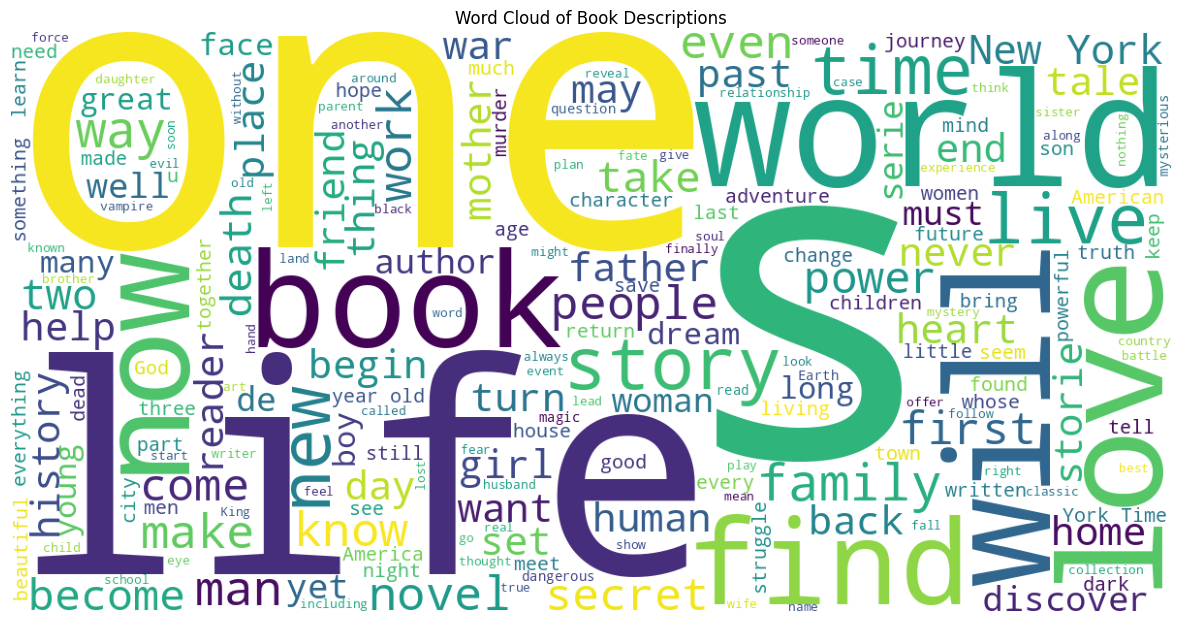

In [ ]:
text = " ".join(df['book_details'].astype(str))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Word Cloud of Book Descriptions")

plt.show()

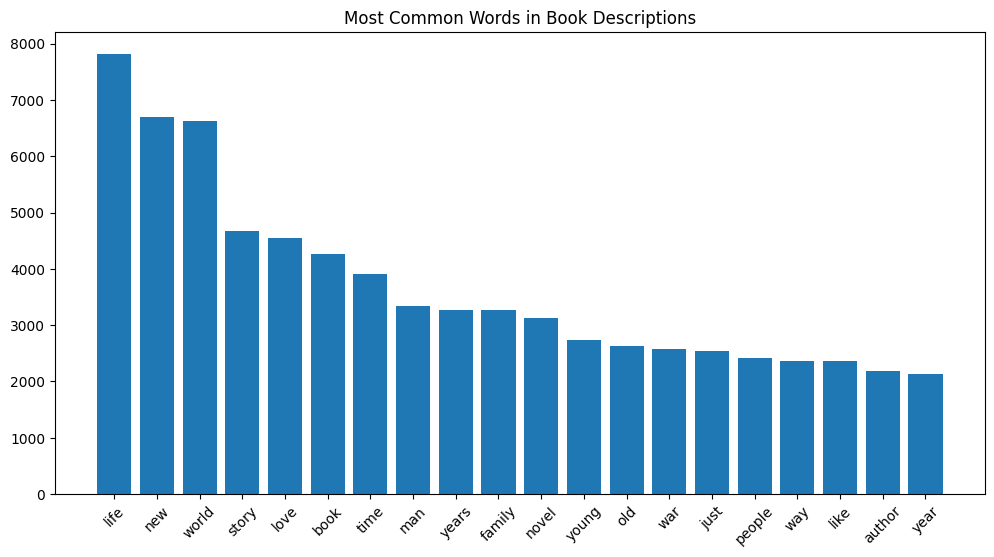

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words='english',
    max_features=20
)

X = vectorizer.fit_transform(df['book_details'])

words = vectorizer.get_feature_names_out()

counts = X.toarray().sum(axis=0)

word_df = pd.DataFrame({
    'Word': words,
    'Frequency': counts
})

word_df = word_df.sort_values(
    by='Frequency',
    ascending=False
)

plt.figure(figsize=(12,6))

plt.bar(word_df['Word'], word_df['Frequency'])

plt.xticks(rotation=45)

plt.title("Most Common Words in Book Descriptions")

plt.show()

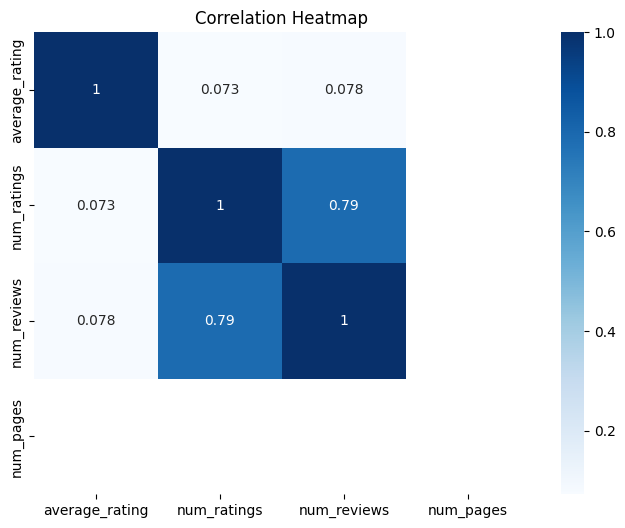

In [ ]:
import seaborn as sns

numeric_cols = [
    'average_rating',
    'num_ratings',
    'num_reviews',
    'num_pages'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Heatmap")

plt.show()

# Step 5: Text Preprocessing

Text preprocessing converts raw textual data into a clean and standardized format suitable for machine learning algorithms. This process includes combining text fields, converting text to lowercase, removing punctuation and numbers, tokenization, stop-word removal, and lemmatization.

In [ ]:
# ===========================================
# Import Libraries for Text Preprocessing
# ===========================================

import re
import string
import nltk
import ast

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
# ===========================================
# Convert Genre List into Text
# ===========================================



import ast

def clean_genres_text(genres):

    # If already a Python list
    if isinstance(genres, list):
        return " ".join(genres)

    # If it's a string representation of a list
    try:
        genre_list = ast.literal_eval(genres)

        if isinstance(genre_list, list):
            return " ".join(genre_list)

    except:
        pass

    # Fallback
    return str(genres)

df["genres_text"] = df["genres"].apply(clean_genres_text)

df[["genres","genres_text"]].head()

,genres,genres_text
0,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...",Fantasy Young Adult Fiction Magic Childrens Au...
1,"['Young Adult', 'Fiction', 'Magic', 'Childrens...",Young Adult Fiction Magic Childrens Audiobook ...
2,"['Fantasy', 'Fiction', 'Young Adult', 'Magic',...",Fantasy Fiction Young Adult Magic Childrens Mi...
3,"['Fantasy', 'Fiction', 'Young Adult', 'Magic',...",Fantasy Fiction Young Adult Magic Childrens Mi...
4,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...",Fantasy Young Adult Fiction Magic Childrens Au...


In [ ]:
# ===========================================
# Combine Text Features
# ===========================================

df['combined_text'] = (
    df['book_title'] + " " +
    df['author'] + " " +
    df['genres_text'] + " " +
    df['book_details']
)

df[['book_title','combined_text']].head()

,book_title,combined_text
0,Harry Potter and the Half-Blood Prince,Harry Potter and the Half-Blood Prince J.K. Ro...
1,Harry Potter and the Order of the Phoenix,Harry Potter and the Order of the Phoenix J.K....
2,Harry Potter and the Sorcerer's Stone,Harry Potter and the Sorcerer's Stone J.K. Row...
3,Harry Potter and the Prisoner of Azkaban,Harry Potter and the Prisoner of Azkaban J.K. ...
4,Harry Potter and the Goblet of Fire,Harry Potter and the Goblet of Fire J.K. Rowli...


In [ ]:
# ===========================================
# Initialize NLP Objects
# ===========================================

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [ ]:
# ===========================================
# Text Cleaning Function
# ===========================================

def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Tokenize
    words = word_tokenize(text)

    # Remove stopwords
    words = [
        word
        for word in words
        if word not in stop_words
    ]

    # Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return " ".join(words)

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
import re
import string

def clean_text(text):

    # Handle missing values
    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Remove very short words
    words = [word for word in words if len(word) > 2]

    # Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [ ]:
df['clean_text'] = df['combined_text'].apply(clean_text)

print("Text preprocessing completed successfully!")

Text preprocessing completed successfully!


In [ ]:
# ===========================================
# Before vs After Cleaning
# ===========================================

print("Original Text:\n")
print(df['combined_text'].iloc[0])

print("\n" + "="*80 + "\n")

print("Cleaned Text:\n")
print(df['clean_text'].iloc[0])

Original Text:

Harry Potter and the Half-Blood Prince J.K. Rowling Fantasy Young Adult Fiction Magic Childrens Audiobook Adventure It is the middle of the summer, but there is an unseasonal mist pressing against the windowpanes. Harry Potter is waiting nervously in his bedroom at the Dursleys' house in Privet Drive for a visit from Professor Dumbledore himself. One of the last times he saw the Headmaster, he was in a fierce one-to-one duel with Lord Voldemort, and Harry can't quite believe that Professor Dumbledore will actually appear at the Dursleys' of all places. Why is the Professor coming to visit him now? What is it that cannot wait until Harry returns to Hogwarts in a few weeks' time? Harry's sixth year at Hogwarts has already got off to an unusual start, as the worlds of Muggle and magic start to intertwine...


Cleaned Text:

harry potter halfblood prince rowling fantasy young adult fiction magic childrens audiobook adventure middle summer unseasonal mist pressing windowpane

# Step 6: Feature Engineering

Feature Engineering converts the cleaned textual data into numerical feature vectors that machine learning algorithms can process.

Two techniques are implemented:

1. Bag of Words (BoW)
2. TF-IDF Vectorization

TF-IDF is later used for building the recommendation engine because it assigns higher importance to informative words while reducing the influence of common words.

In [ ]:
# ===========================================
# Bag of Words (BoW)
# ===========================================

from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(
    max_features=5000
)

bow_matrix = bow_vectorizer.fit_transform(df['clean_text'])

print("Bag of Words Matrix Shape:")
print(bow_matrix.shape)

Bag of Words Matrix Shape:
(15443, 5000)


In [ ]:
# Vocabulary Size

print("Vocabulary Size:")
print(len(bow_vectorizer.vocabulary_))

Vocabulary Size:
5000


In [ ]:
# Display first 20 words in the vocabulary

feature_names = bow_vectorizer.get_feature_names_out()

print(feature_names[:20])

['aaron' 'abandon' 'abandoned' 'abbey' 'abby' 'abducted' 'ability' 'able'
 'aboard' 'abroad' 'absence' 'absolute' 'absolutely' 'absorbing' 'absurd'
 'abuse' 'abusive' 'academic' 'academy' 'accept']


In [ ]:
# ===========================================
# TF-IDF Vectorization
# ===========================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(df['clean_text'])

print("TF-IDF Matrix Shape:")
print(tfidf_matrix.shape)

TF-IDF Matrix Shape:
(15443, 5000)


In [ ]:
print("Vocabulary Size:")
print(len(tfidf.vocabulary_))

Vocabulary Size:
5000


In [ ]:
print(tfidf.get_feature_names_out()[:20])

['aaron' 'abandon' 'abandoned' 'abbey' 'abby' 'abducted' 'ability' 'able'
 'aboard' 'abroad' 'absence' 'absolute' 'absolutely' 'absorbing' 'absurd'
 'abuse' 'abusive' 'academic' 'academy' 'accept']


## Comparison of Bag of Words and TF-IDF

Bag of Words represents text using raw word frequencies, whereas TF-IDF assigns higher importance to informative words and lower importance to very common words. Since TF-IDF captures the significance of words more effectively, it is selected for building the recommendation engine.

In [ ]:
print("="*50)

print("Bag of Words Shape :", bow_matrix.shape)

print("TF-IDF Shape       :", tfidf_matrix.shape)

print("="*50)

Bag of Words Shape : (15443, 5000)
TF-IDF Shape       : (15443, 5000)


# Step 7: Cosine Similarity

Cosine Similarity measures the similarity between books by comparing their TF-IDF vectors. Books with similar textual content have higher cosine similarity scores and are recommended to the user.

In [ ]:
# ===========================================
# Cosine Similarity
# ===========================================

from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix)

print("Cosine Similarity Matrix Shape:")

print(cosine_sim.shape)

Cosine Similarity Matrix Shape:
(15443, 15443)


# Step 8: Content-Based Recommendation Engine

The recommendation engine uses Content-Based Filtering. It compares the TF-IDF vector of the selected book with all other books using Cosine Similarity and recommends the Top-N most similar books.

In [ ]:
# ===========================================
# Create Title Index Mapping
# ===========================================

indices = pd.Series(
    df.index,
    index=df['book_title']
).drop_duplicates()

print("Index mapping created successfully!")

Index mapping created successfully!


In [ ]:
# ===========================================
# Recommendation Function
# ===========================================

import ast

def recommend_books(title, top_n=10):

    # Check if the book exists
    if title not in indices:
        print("Book not found in the dataset.")
        return

    # Get index of selected book
    idx = indices[title]

    # Get similarity scores
    similarity_scores = list(enumerate(cosine_sim[idx]))

    # Sort by similarity
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Ignore the first result (the selected book itself)
    similarity_scores = similarity_scores[1:top_n+1]

    # Extract indices
    book_indices = [i[0] for i in similarity_scores]

    # Create recommendations DataFrame
    recommendations = df.iloc[book_indices][[
        'book_title',
        'author',
        'average_rating',
        'genres'
    ]].copy()

    # Convert genres into a readable format
    recommendations['genres'] = recommendations['genres'].apply(
        lambda x: ", ".join(ast.literal_eval(x)) if isinstance(x, str) else x
    )

    # Add similarity scores
    recommendations["Similarity Score"] = [
        round(score, 3)
        for _, score in similarity_scores
    ]

    print(f"\nTop {top_n} recommendations for: {title}\n")

    return recommendations.reset_index(drop=True)

In [ ]:
recommend_books("Harry Potter and the Half-Blood Prince")


Top 10 recommendations for: Harry Potter and the Half-Blood Prince



,book_title,author,average_rating,genres,Similarity Score
0,Harry Potter and the Chamber of Secrets,J.K. Rowling,4.43,"Fantasy, Fiction, Young Adult, Magic, Children...",0.547
1,"Harry Potter Boxed Set, Books 1-5",J.K. Rowling,4.72,"Fantasy, Young Adult, Fiction, Magic, Adventur...",0.545
2,The Harry Potter Collection 1-4,J.K. Rowling,4.69,"Fantasy, Fiction, Young Adult, Magic, Adventur...",0.512
3,Harry Potter and the Goblet of Fire,J.K. Rowling,4.57,"Fantasy, Young Adult, Fiction, Magic, Children...",0.495
4,Harry Potter and the Methods of Rationality,Eliezer Yudkowsky,4.39,"Fantasy, Fiction, Fan Fiction, Philosophy, Sci...",0.494
5,Harry Potter and the Cursed Child. Parts One a...,J.K. Rowling,3.49,"Fantasy, Fiction, Young Adult, Plays, Magic, A...",0.471
6,Harry Potter and the Prisoner of Azkaban,J.K. Rowling,4.58,"Fantasy, Fiction, Young Adult, Magic, Children...",0.468
7,Harry Potter Series Box Set,J.K. Rowling,4.74,"Fantasy, Young Adult, Fiction, Magic, Children...",0.466
8,Harry Potter and the Order of the Phoenix,J.K. Rowling,4.50,"Young Adult, Fiction, Magic, Childrens, Audiob...",0.461
9,Harry Potter and the Sorcerer's Stone,J.K. Rowling,4.47,"Fantasy, Fiction, Young Adult, Magic, Children...",0.443


In [ ]:
recommend_books("The Hobbit")


Top 10 recommendations for: The Hobbit



,book_title,author,average_rating,genres,Similarity Score
0,The Toughest Indian in the World,Sherman Alexie,4.08,"Fiction, Short Stories, Literature, Literary F...",0.208
1,হাজার চুরাশির মা,Mahasweta Devi,4.22,"Fiction, India, Historical Fiction, Classics, ...",0.207
2,The Haunted Hotel & Other Stories,Wilkie Collins,3.69,"Classics, Horror, Short Stories, Gothic, Ficti...",0.206
3,The Indian In The Cupboard Trilogy,Lynne Reid Banks,4.09,"Fantasy, Fiction, Childrens, Adventure, Young ...",0.205
4,Flashman at the Charge,George MacDonald Fraser,4.37,"Historical Fiction, Fiction, Historical, Humor...",0.201
5,The Suspicions of Mr. Whicher: Murder and the ...,Kate Summerscale,3.51,"Nonfiction, True Crime, History, Mystery, Crim...",0.194
6,The Woman in White,Wilkie Collins,4.01,"Classics, Mystery, Gothic, Horror, 19th Centur...",0.193
7,The Bridge To Caracas,Stephen Douglass,3.69,"Thriller, Crime, Romance, Mystery, Amazon, Fic...",0.191
8,The Indian in the Cupboard,Lynne Reid Banks,3.93,"Fantasy, Childrens, Fiction, Young Adult, Clas...",0.187
9,Ballistics,Billy Collins,4.09,"Poetry, American, Nonfiction, Contemporary, Ad...",0.185


# Step 9: Evaluation

The recommendation engine was evaluated qualitatively by testing it with popular books. The system successfully recommends books with similar genres, themes, authors, or writing styles based on textual similarity using TF-IDF and Cosine Similarity.

In [ ]:
# Test with three books

recommend_books("Harry Potter and the Half-Blood Prince")


Top 10 recommendations for: Harry Potter and the Half-Blood Prince



,book_title,author,average_rating,genres,Similarity Score
0,Harry Potter and the Chamber of Secrets,J.K. Rowling,4.43,"Fantasy, Fiction, Young Adult, Magic, Children...",0.547
1,"Harry Potter Boxed Set, Books 1-5",J.K. Rowling,4.72,"Fantasy, Young Adult, Fiction, Magic, Adventur...",0.545
2,The Harry Potter Collection 1-4,J.K. Rowling,4.69,"Fantasy, Fiction, Young Adult, Magic, Adventur...",0.512
3,Harry Potter and the Goblet of Fire,J.K. Rowling,4.57,"Fantasy, Young Adult, Fiction, Magic, Children...",0.495
4,Harry Potter and the Methods of Rationality,Eliezer Yudkowsky,4.39,"Fantasy, Fiction, Fan Fiction, Philosophy, Sci...",0.494
5,Harry Potter and the Cursed Child. Parts One a...,J.K. Rowling,3.49,"Fantasy, Fiction, Young Adult, Plays, Magic, A...",0.471
6,Harry Potter and the Prisoner of Azkaban,J.K. Rowling,4.58,"Fantasy, Fiction, Young Adult, Magic, Children...",0.468
7,Harry Potter Series Box Set,J.K. Rowling,4.74,"Fantasy, Young Adult, Fiction, Magic, Children...",0.466
8,Harry Potter and the Order of the Phoenix,J.K. Rowling,4.50,"Young Adult, Fiction, Magic, Childrens, Audiob...",0.461
9,Harry Potter and the Sorcerer's Stone,J.K. Rowling,4.47,"Fantasy, Fiction, Young Adult, Magic, Children...",0.443


In [ ]:
import pickle

pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))
pickle.dump(cosine_sim, open("cosine_similarity.pkl", "wb"))

print("Model files saved successfully!")

Model files saved successfully!


In [ ]:
df.to_csv("cleaned_books_dataset.csv", index=False)

In [ ]:
from google.colab import files

files.download("cleaned_books_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>